# Decision Tree - Diabetes Classification

This notebook implements the Decision Tree algorithm for the diabetes classification problem.


In [1]:
# Importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree, export_text
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)


In [2]:
# Load the dataset

dataset_path = Path("../dataset/diabetes_prediction_dataset_2000.csv")
df = pd.read_csv(dataset_path)
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,13.0,0,0,No Info,20.82,5.8,126,0
1,Female,3.0,0,0,No Info,21.00,5.0,145,0
2,Male,63.0,0,0,former,25.32,3.5,200,0
3,Female,2.0,0,0,never,17.43,6.1,126,0
4,Female,33.0,0,0,not current,40.08,6.2,200,1


In [3]:
# Basic dataset checking

print("Dataset shape:", df.shape)
print("\nDataset information:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Dataset shape: (2000, 9)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               2000 non-null   object 
 1   age                  2000 non-null   float64
 2   hypertension         2000 non-null   int64  
 3   heart_disease        2000 non-null   int64  
 4   smoking_history      2000 non-null   object 
 5   bmi                  2000 non-null   float64
 6   HbA1c_level          2000 non-null   float64
 7   blood_glucose_level  2000 non-null   int64  
 8   diabetes             2000 non-null   int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 140.8+ KB
None

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes   

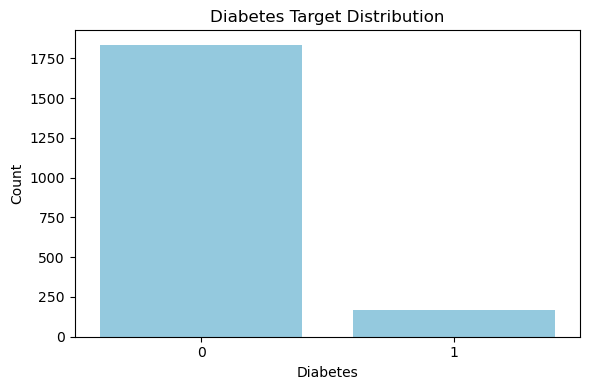

In [4]:
# Target distribution

plt.figure(figsize=(6, 4))
sns.countplot(x=df["diabetes"], color="skyblue")
plt.title("Diabetes Target Distribution")
plt.xlabel("Diabetes")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### Insight

The target variable contains two classes, 0 for patients without diabetes and 1 for patients with diabetes. The plot shows that the two classes are not equally distributed, so stratified splitting is used later to keep a similar target proportion in the training and testing sets.


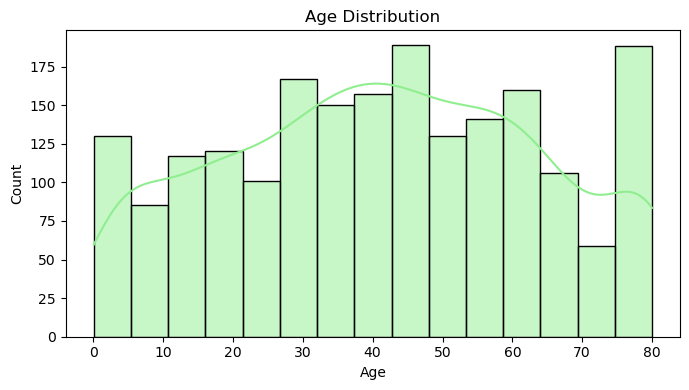

In [5]:
# Numerical feature distributions

plt.figure(figsize=(7, 4))
sns.histplot(df["age"], kde=True, color="lightgreen")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### Insight

The age distribution shows that the dataset contains patients from different age groups, with more observations concentrated in the middle age ranges.


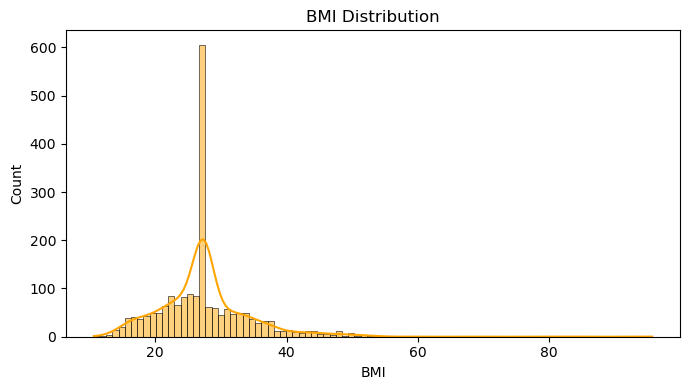

In [6]:
plt.figure(figsize=(7, 4))
sns.histplot(df["bmi"], kde=True, color="orange")
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### Insight

The BMI values are spread across a wide range, with most observations concentrated around the middle of the distribution and fewer observations at the higher values.


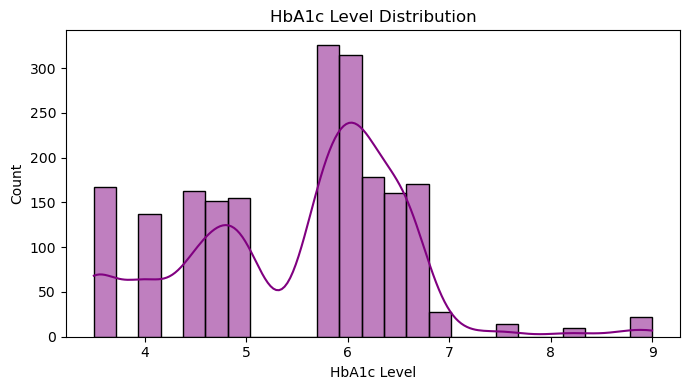

In [7]:
plt.figure(figsize=(7, 4))
sns.histplot(df["HbA1c_level"], kde=True, color="purple")
plt.title("HbA1c Level Distribution")
plt.xlabel("HbA1c Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### Insight

The HbA1c level distribution shows that most observations are concentrated in a lower range, while some patients have higher HbA1c values.


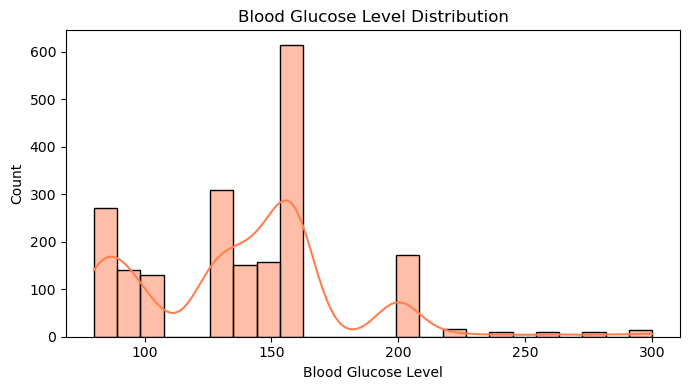

In [8]:
plt.figure(figsize=(7, 4))
sns.histplot(df["blood_glucose_level"], kde=True, color="coral")
plt.title("Blood Glucose Level Distribution")
plt.xlabel("Blood Glucose Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### Insight

The blood glucose distribution contains a wider spread, with a smaller number of observations having higher glucose levels. These higher values are important when studying diabetes-related patterns.


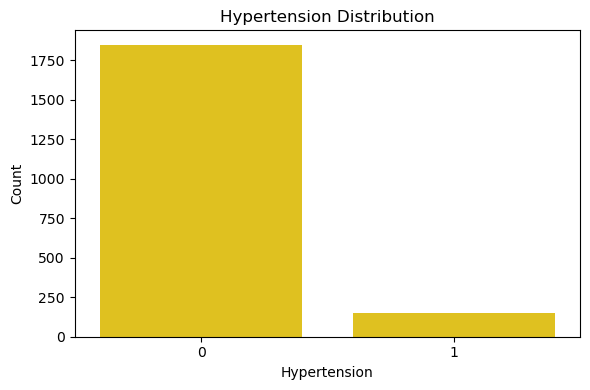

In [9]:
# Binary feature distributions

plt.figure(figsize=(6, 4))
sns.countplot(x=df["hypertension"], color="gold")
plt.title("Hypertension Distribution")
plt.xlabel("Hypertension")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### Insight

Hypertension is a binary feature with values 0 and 1. Most observations have a value of 0, so the feature is imbalanced toward patients without hypertension.


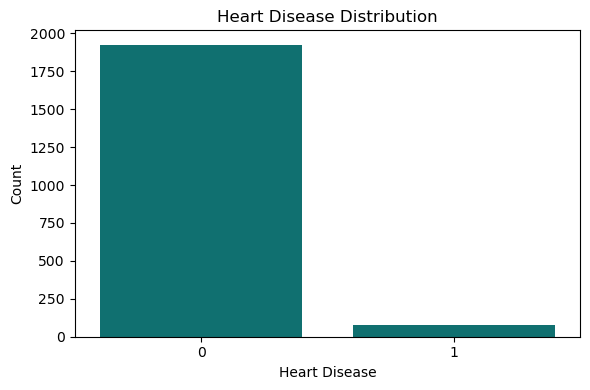

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df["heart_disease"], color="teal")
plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### Insight

Heart disease is also a binary feature, and most patients in the dataset have a value of 0. This shows that heart disease is less common in this dataset than its absence.


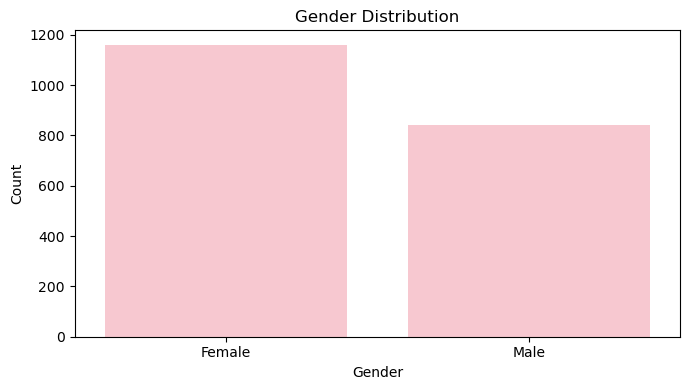

In [11]:
# Categorical feature distributions

plt.figure(figsize=(7, 4))
sns.countplot(x=df["gender"], color="pink")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### Insight

The gender distribution shows the number of patients in each gender category. The categories are not perfectly balanced, but all main categories are represented in the dataset.


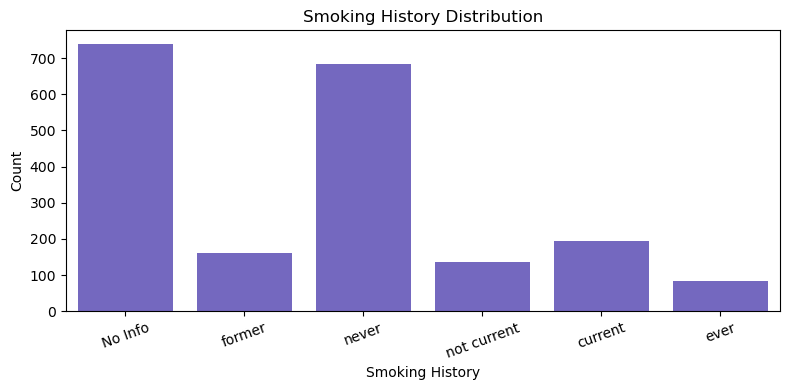

In [12]:
plt.figure(figsize=(8, 4))
sns.countplot(x=df["smoking_history"], color="slateblue")
plt.title("Smoking History Distribution")
plt.xlabel("Smoking History")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### Insight

The smoking history categories have different frequencies. Some categories contain considerably more patients than others, showing that this feature is not evenly distributed.


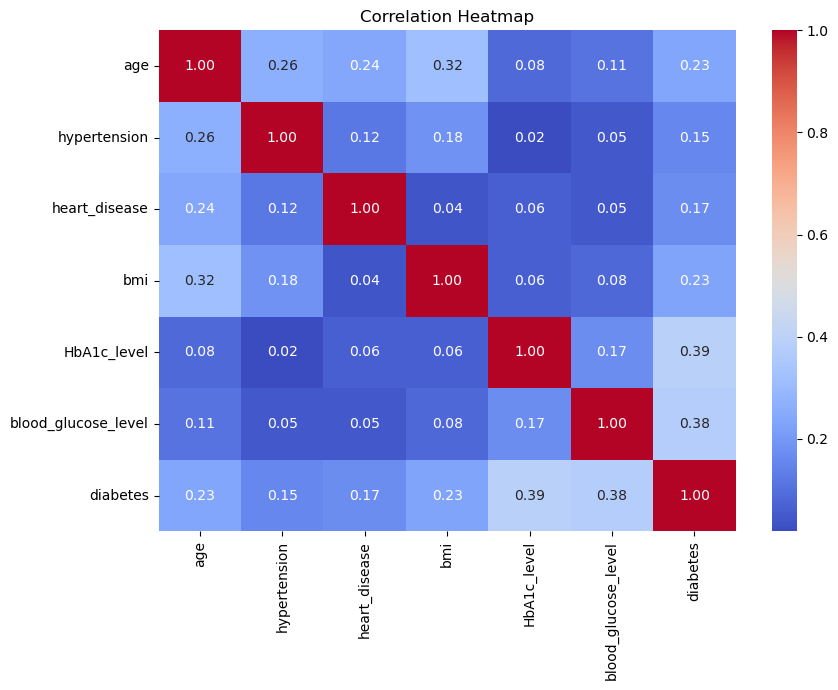

In [13]:
# Correlation heatmap

plt.figure(figsize=(9, 7))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


### Insight

The correlation heatmap shows the relationships among the numerical variables. Blood glucose level and HbA1c level show noticeable relationships with the diabetes target compared with several other numerical features.


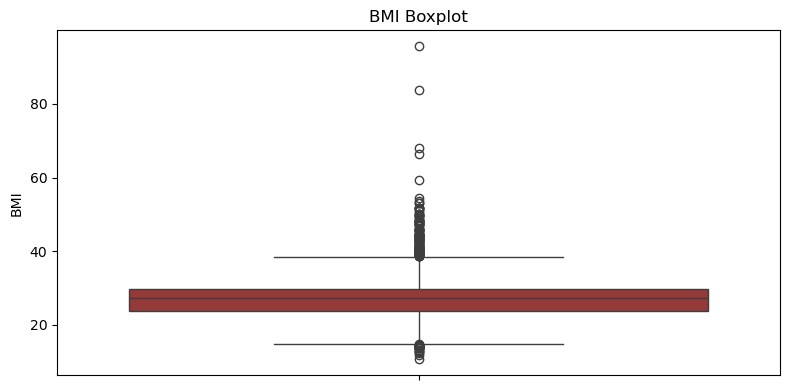

In [14]:
# Boxplots for outlier checking

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(y=df["bmi"], color="brown", ax=ax)
ax.set_title("BMI Boxplot")
ax.set_ylabel("BMI")
plt.tight_layout()
plt.show()


### Insight

The BMI boxplot shows the spread of the feature and highlights observations that are far from the main range. These values are checked using the IQR method before model training.


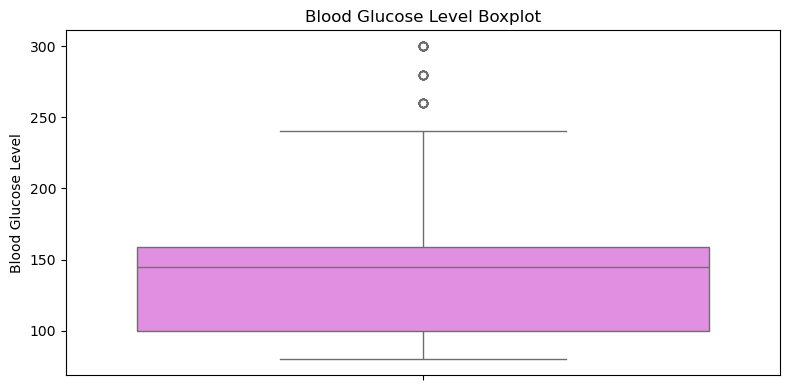

In [15]:
plt.figure(figsize=(8, 4))
sns.boxplot(y=df["blood_glucose_level"], color="violet")
plt.title("Blood Glucose Level Boxplot")
plt.ylabel("Blood Glucose Level")
plt.tight_layout()
plt.show()


### Insight

The blood glucose boxplot shows a wider spread and some high-value observations. These observations are considered during the outlier treatment step.


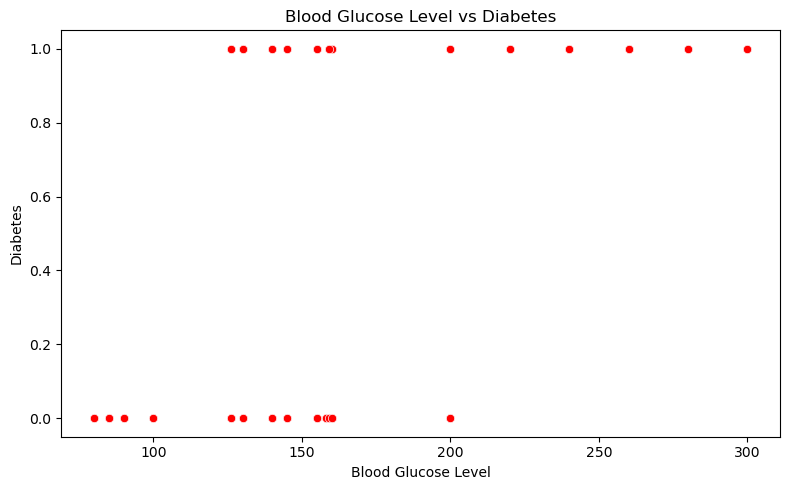

In [16]:
# Scatter plot: glucose and diabetes

plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=df["blood_glucose_level"],
    y=df["diabetes"],
    color="red"
)
plt.title("Blood Glucose Level vs Diabetes")
plt.xlabel("Blood Glucose Level")
plt.ylabel("Diabetes")
plt.tight_layout()
plt.show()


### Insight

The scatter plot shows that diabetes-positive observations appear more frequently at higher blood glucose levels. This suggests that blood glucose level is an important feature for the classification problem.


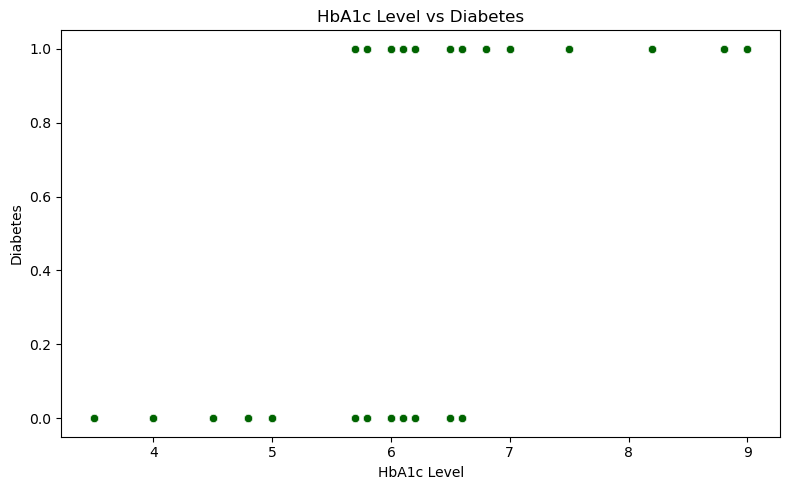

In [17]:
# Scatter plot: HbA1c and diabetes

plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=df["HbA1c_level"],
    y=df["diabetes"],
    color="darkgreen"
)
plt.title("HbA1c Level vs Diabetes")
plt.xlabel("HbA1c Level")
plt.ylabel("Diabetes")
plt.tight_layout()
plt.show()


### Insight

The scatter plot shows that diabetes-positive observations are more common at higher HbA1c levels. This indicates that HbA1c level has a useful relationship with the target variable.


In [18]:
# Remove duplicate rows

before = len(df)
df = df.drop_duplicates()
after = len(df)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Duplicates removed:", before - after)


Rows before removing duplicates: 2000
Rows after removing duplicates: 1996
Duplicates removed: 4


In [19]:
# Handle missing values

print("Missing values before treatment:")
print(df.isnull().sum())

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

print("\nMissing values after treatment:")
print(df.isnull().sum())


Missing values before treatment:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Missing values after treatment:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [20]:
# Check and treat outliers using the IQR method

outlier_cols = [
    "bmi",
    "HbA1c_level",
    "blood_glucose_level"
]

outlier_summary = []

for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        "Feature": col,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outliers Found": count
    })
    df[col] = df[col].clip(lower=lower, upper=upper)

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary

,Feature,Lower Bound,Upper Bound,Outliers Found
0,bmi,14.66375,38.61375,143
1,HbA1c_level,2.70000,8.30000,22
2,blood_glucose_level,11.50000,247.50000,33


In [21]:
for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    remaining = ((df[col] < lower) | (df[col] > upper)).sum()
    print(col, "Outliers After Treatment:", remaining)

bmi Outliers After Treatment: 0
HbA1c_level Outliers After Treatment: 0
blood_glucose_level Outliers After Treatment: 0


In [22]:
# Separating features and target

x = df.drop("diabetes", axis=1)
y = df["diabetes"]

print("Features:")
print(x.head())
print("\nTarget:")
print(y.head())


Features:
   gender   age  hypertension  heart_disease smoking_history       bmi  \
0  Female  13.0             0              0         No Info  20.82000   
1  Female   3.0             0              0         No Info  21.00000   
2    Male  63.0             0              0          former  25.32000   
3  Female   2.0             0              0           never  17.43000   
4  Female  33.0             0              0     not current  38.61375   

   HbA1c_level  blood_glucose_level  
0          5.8                126.0  
1          5.0                145.0  
2          3.5                200.0  
3          6.1                126.0  
4          6.2                200.0  

Target:
0    0
1    0
2    0
3    0
4    1
Name: diabetes, dtype: int64


In [23]:
# Feature engineering

df["glucose_hba1c_interaction"] = (df["blood_glucose_level"] * df["HbA1c_level"])
x = df.drop("diabetes", axis=1)
y = df["diabetes"]
print("Engineered feature added: glucose_hba1c_interaction")

Engineered feature added: glucose_hba1c_interaction


### Feature Engineering Justification

The interaction feature `glucose_hba1c_interaction` combines blood glucose level and HbA1c level into one feature. Both variables are related to blood sugar levels, so their interaction may provide additional information about diabetes patterns that is not captured by either feature alone.


In [24]:
# Identify numerical and categorical features

num_features = x.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = x.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical features:")
print(num_features)

print("\nCategorical features:")
print(cat_features)

Numerical features:
['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'glucose_hba1c_interaction']

Categorical features:
['gender', 'smoking_history']


In [25]:
# Preprocessing

prep = ColumnTransformer(
    transformers=[
        ("numerical", StandardScaler(), num_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features)
    ]
)

In [26]:
# Stratified train-test split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", x_train.shape)
print("Testing set:", x_test.shape)

Training set: (1596, 9)
Testing set: (400, 9)


In [27]:
# Create Decision Tree Classifier

dt_model = Pipeline(
    steps=[
        ("preprocessing", prep),
        ("decision_tree", DecisionTreeClassifier(
            random_state=42,
            max_depth=5,
            criterion="entropy"
        ))
    ]
)
dt_model

,steps,"[('preprocessing', ...), ('decision_tree', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [28]:
# Train the model

dt_model.fit(x_train, y_train)
print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [29]:
# Model predictions

dt_pred = dt_model.predict(x_test)
dt_prob = dt_model.predict_proba(x_test)[:, 1]

print("Predictions:")
print(dt_pred[:10])


Predictions:
[0 0 0 0 0 0 0 0 0 0]


In [30]:
# Calculate evaluation metrics

dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred, zero_division=0)
dt_recall = recall_score(y_test, dt_pred, zero_division=0)
dt_f1 = f1_score(y_test, dt_pred, average="weighted")
dt_auc = roc_auc_score(y_test, dt_prob)

print("Decision Tree Performance")
print("Accuracy :", round(dt_accuracy, 4))
print("Precision:", round(dt_precision, 4))
print("Recall   :", round(dt_recall, 4))
print("Weighted F1:", round(dt_f1, 4))
print("ROC-AUC  :", round(dt_auc, 4))


Decision Tree Performance
Accuracy : 0.9625
Precision: 1.0
Recall   : 0.5455
Weighted F1: 0.9574
ROC-AUC  : 0.9536


In [31]:
# Classification report

print("Decision Tree Classification Report")
print(
    classification_report(
        y_test,
        dt_pred,
        target_names=["No Diabetes", "Diabetes"],
        zero_division=0
    )
)


Decision Tree Classification Report
              precision    recall  f1-score   support

 No Diabetes       0.96      1.00      0.98       367
    Diabetes       1.00      0.55      0.71        33

    accuracy                           0.96       400
   macro avg       0.98      0.77      0.84       400
weighted avg       0.96      0.96      0.96       400



Decision Tree Structure:
|--- numerical__HbA1c_level <= 1.16
|   |--- numerical__blood_glucose_level <= 1.89
|   |   |--- numerical__glucose_hba1c_interaction <= -0.14
|   |   |   |--- class: 0
|   |   |--- numerical__glucose_hba1c_interaction >  -0.14
|   |   |   |--- numerical__age <= 0.68
|   |   |   |   |--- numerical__bmi <= 0.10
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- numerical__bmi >  0.10
|   |   |   |   |   |--- class: 0
|   |   |   |--- numerical__age >  0.68
|   |   |   |   |--- numerical__bmi <= 1.42
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- numerical__bmi >  1.42
|   |   |   |   |   |--- class: 0
|   |--- numerical__blood_glucose_level >  1.89
|   |   |--- class: 1
|--- numerical__HbA1c_level >  1.16
|   |--- class: 1



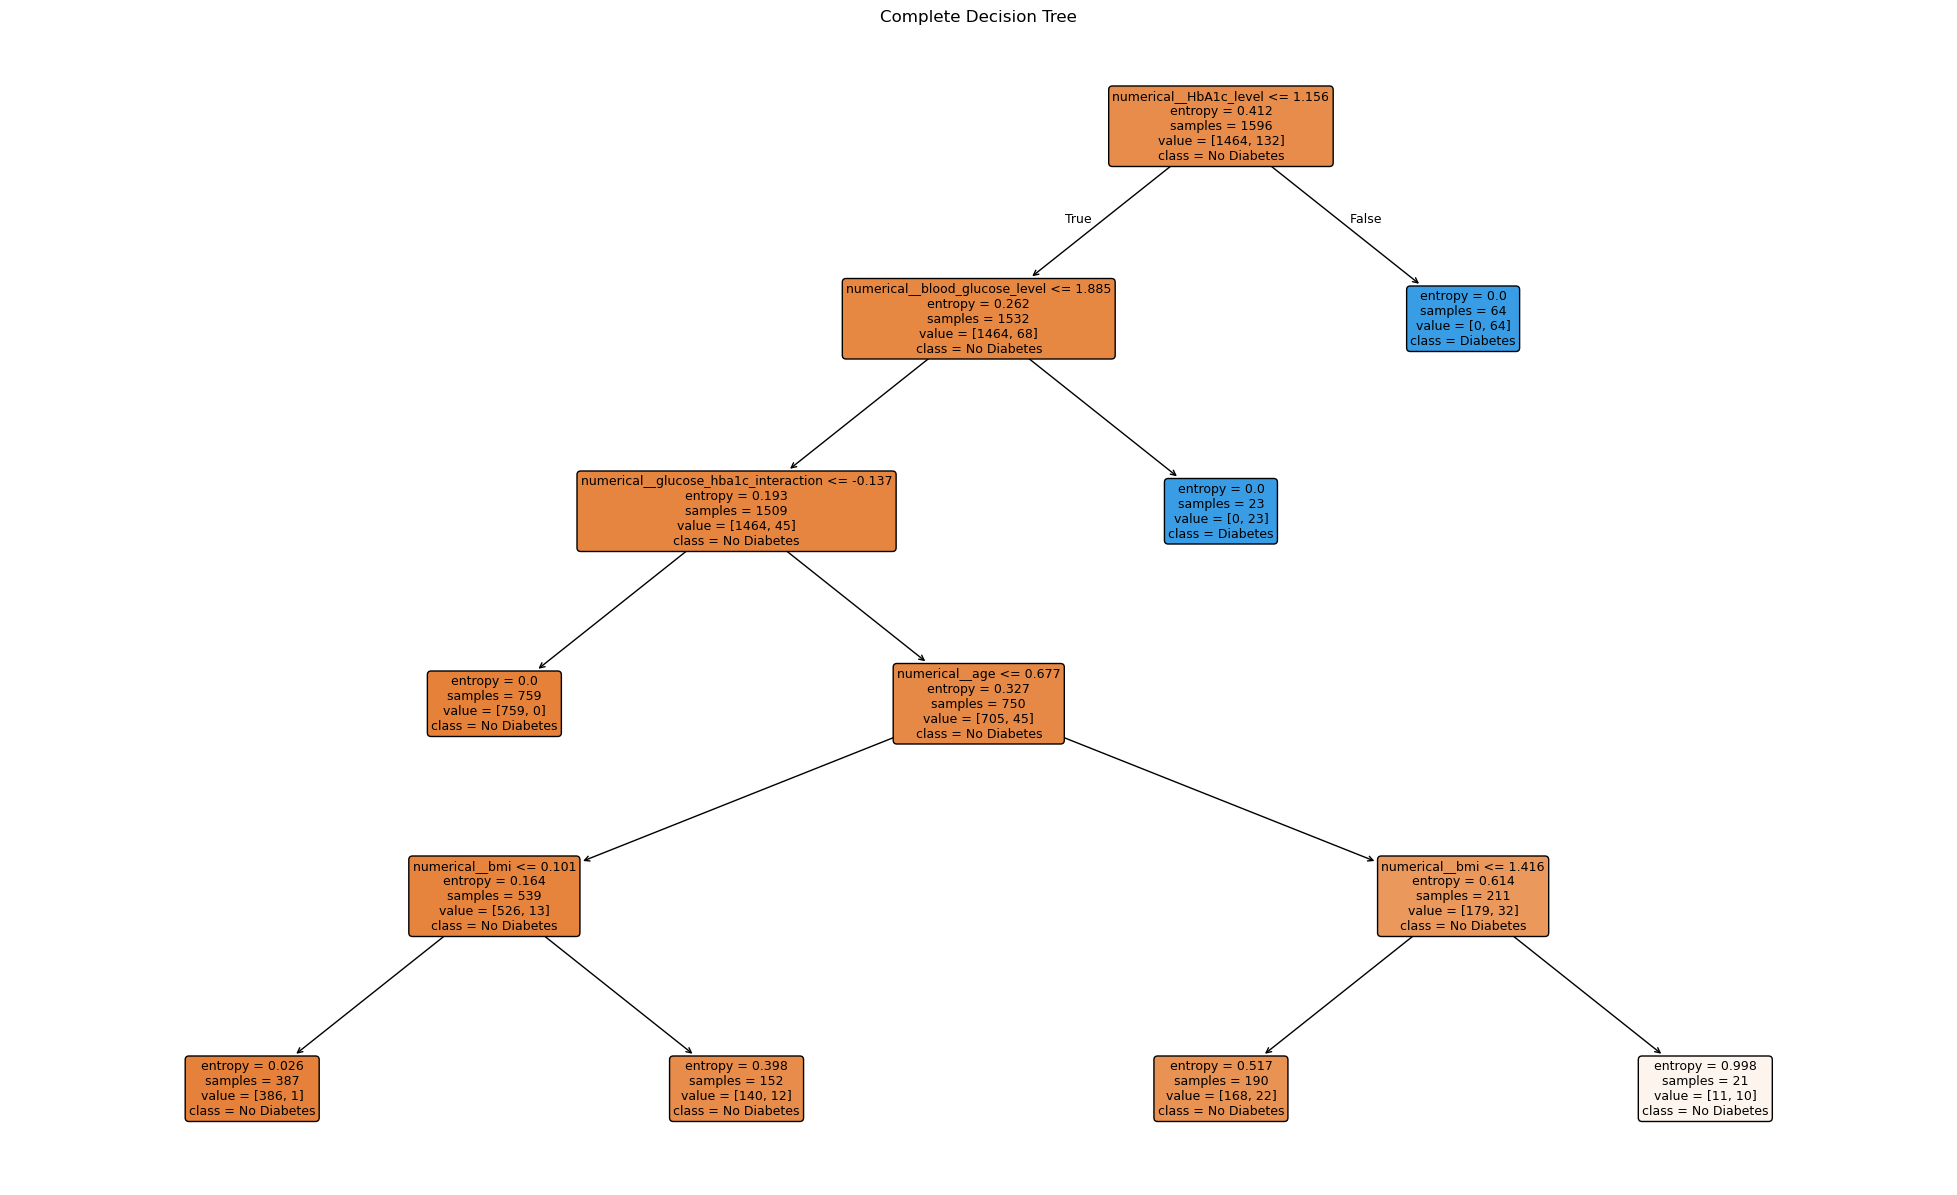

In [32]:
dt_preprocessor = dt_model.named_steps["preprocessing"]
dt_classifier = dt_model.named_steps["decision_tree"]

feature_names = dt_preprocessor.get_feature_names_out()

print("Decision Tree Structure:")
print(export_text(
    dt_classifier,
    feature_names=list(feature_names)
))

plt.figure(figsize=(25, 15))
plot_tree(
    dt_classifier,
    feature_names=feature_names,
    class_names=["No Diabetes", "Diabetes"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Complete Decision Tree")
plt.show()

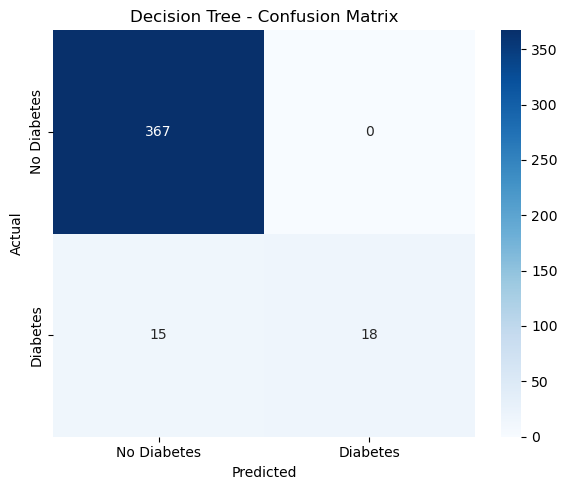

In [33]:
# Confusion Matrix

cm_dt = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


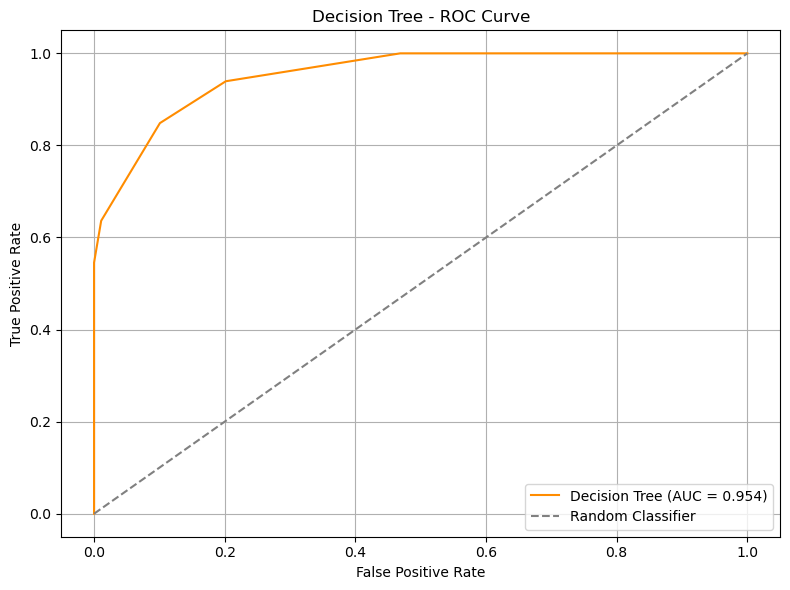

In [34]:
# ROC Curve

dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)

plt.figure(figsize=(8, 6))
plt.plot(
    dt_fpr,
    dt_tpr,
    color="darkorange",
    label=f"Decision Tree (AUC = {dt_auc:.3f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    color="gray",
    linestyle="--",
    label="Random Classifier"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree - ROC Curve")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [35]:
# Feature Importance

dt_preprocessor = dt_model.named_steps["preprocessing"]
dt_classifier = dt_model.named_steps["decision_tree"]

feature_names = dt_preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": dt_classifier.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)


,Feature,Importance
4,numerical__HbA1c_level,0.546960
5,numerical__blood_glucose_level,0.234362
6,numerical__glucose_hba1c_interaction,0.099320
3,numerical__bmi,0.060171
0,numerical__age,0.059186
1,numerical__hypertension,0.000000
2,numerical__heart_disease,0.000000
7,categorical__gender_Female,0.000000
8,categorical__gender_Male,0.000000
9,categorical__smoking_history_No Info,0.000000


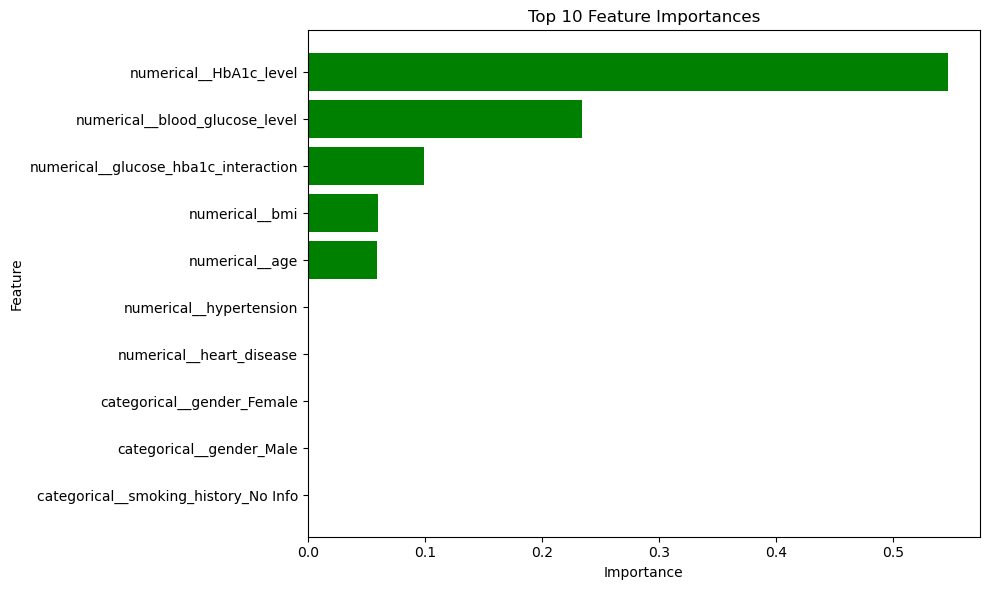

In [36]:
# Plot top feature importances

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1],
    color="green"
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()


### Insight

The feature importance plot shows which transformed features contributed most to the Decision Tree predictions. Features with higher importance had a larger contribution to the tree's decisions.


In [37]:
import os

os.makedirs("../results", exist_ok=True)
results_path = "../results/classification_results.csv"

row = pd.DataFrame([{
    "Model": "Decision Tree",
    "Accuracy": dt_accuracy,
    "Precision": dt_precision,
    "Recall": dt_recall,
    "Weighted F1": dt_f1,
    "ROC-AUC": dt_auc
}])

if os.path.exists(results_path):
    saved = pd.read_csv(results_path)
    saved = saved[saved["Model"] != "Decision Tree"]
    row = pd.concat([saved, row], ignore_index=True)

row.to_csv(results_path, index=False)

os.makedirs("../results/predictions", exist_ok=True)

pd.DataFrame({
    "y_test": y_test.values,
    "y_pred": dt_pred,
    "y_prob": dt_prob
}).to_csv(
    "../results/predictions/Decision Tree.csv",
    index=False
)

row = pd.read_csv(results_path)

row.sort_values(
    "Weighted F1",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,Weighted F1,ROC-AUC
0,Decision Tree,0.9625,1.000000,0.545455,0.957361,0.953596
1,K-Nearest Neighbors,0.9550,0.894737,0.515152,0.949363,0.868095
2,Logistic Regression,0.9450,0.761905,0.484848,0.939331,0.943522
3,Gaussian Naive Bayes,0.9000,0.438596,0.757576,0.911643,0.935596
